# Experiment: Analysis of Deep Network Training Difficulties

**Objective:**
To investigate why deep feedforward neural networks were historically difficult to train with standard random initialization and to verify the effectiveness of the **Normalized (Xavier) Initialization** proposed by Glorot & Bengio (2010).

**The Task:**
The network must classify handwritten digits from the MNIST dataset (784 inputs, 10 outputs) using a deep architecture of **5 hidden layers** (1,000 units each).

**Hypothesis:**
Standard initialization ($U[-1/\sqrt{n}, 1/\sqrt{n}]$) causes the variance of back-propagated gradients to vanish or explode in deep architectures. The Normalized Initialization will keep the variance of activations and gradients constant across layers, preventing saturation and enabling faster convergence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model import DeepMLP, Loss
from train import prepare_data, train_model

# Load MNIST data (50k Train, 10k Val, 10k Test)
X_train, y_train, X_val, y_val, X_test, y_test = prepare_data()

# Define common architecture for investigation (5 hidden layers)
layer_sizes = [784, 1000, 1000, 1000, 1000, 1000, 10]

Loading MNIST...


## Experimental Methodology

We implement the investigative experiments described in the paper to monitor the internal "health" of the network.

**Architecture:**
* **Input Layer:** 784 Units (Pixels)
* **Hidden Layers:** 5 Layers (1,000 units each) to test depth sensitivity
* **Output Layer:** 10 Units (Softmax)

**Configurations for Comparison:**
1. **Standard Tanh:** Tanh activation + Standard Initialization.
2. **Xavier Tanh:** Tanh activation + Normalized Initialization.
3. **Standard Sigmoid:** Sigmoid activation + Standard Initialization (to observe saturation).

In [2]:
# 1. Standard Sigmoid (To observe saturation Figure 2)
config_sig = {'layer_sizes': layer_sizes, 'activation': 'sigmoid',
              'init_type': 'standard', 'lr': 0.01, 'epochs': 20}
model_sig, stats_sig = train_model(X_train, y_train, X_val, y_val, config_sig)

# 2. Tanh with Standard Init
config_tanh_std = {'layer_sizes': layer_sizes, 'activation': 'tanh',
                   'init_type': 'standard', 'lr': 0.01, 'epochs': 1}
model_std, stats_std = train_model(X_train, y_train, X_val, y_val, config_tanh_std)

# 3. Tanh with Xavier Init
config_tanh_xav = {'layer_sizes': layer_sizes, 'activation': 'tanh',
                   'init_type': 'xavier', 'lr': 0.01, 'epochs': 1}
model_xav, stats_xav = train_model(X_train, y_train, X_val, y_val, config_tanh_xav)

Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.
Epoch 6 finished.
Epoch 7 finished.
Epoch 8 finished.
Epoch 9 finished.
Epoch 10 finished.
Epoch 11 finished.
Epoch 12 finished.
Epoch 13 finished.
Epoch 14 finished.
Epoch 15 finished.
Epoch 16 finished.
Epoch 17 finished.
Epoch 18 finished.
Epoch 19 finished.
Epoch 20 finished.
Epoch 1 finished.
Epoch 1 finished.


## Results: Learning Dynamics

A successful initialization should prevent the network from entering long plateaus. We monitor the mean activation values of each layer to identify "saturation" where the layers stop passing useful gradient information.

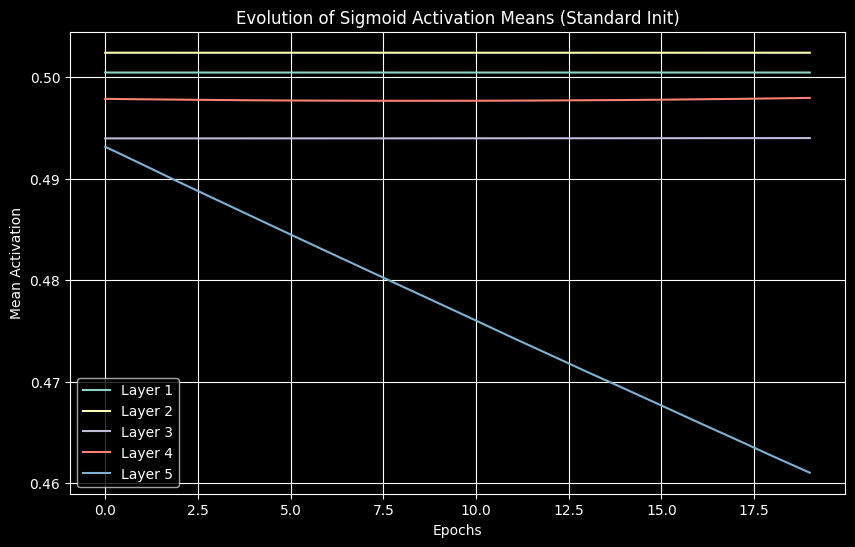

In [3]:
plt.figure(figsize=(10, 6))
means = np.array(stats_sig['activation_means'])
for i in range(5):
    plt.plot(means[:, i], label=f'Layer {i+1}')

plt.title("Evolution of Sigmoid Activation Means (Standard Init)")
plt.xlabel("Epochs")
plt.ylabel("Mean Activation")
plt.legend()
plt.grid(True)
plt.show()
# Observations: Note how top layers (Layer 5) often drop toward zero.

## Investigative Study: Hidden Unit Saturation

By plotting histograms of the activations, we can see if units are clumping at the extremes of the activation functions. The paper claims that **Softsign** or **Xavier-initialized Tanh** avoids the saturation seen in Sigmoid.

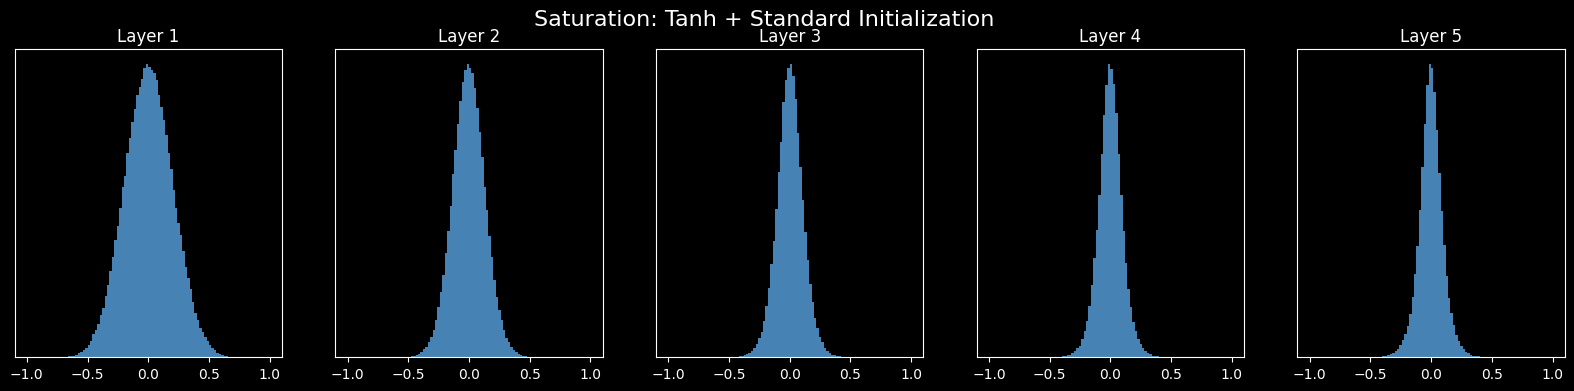

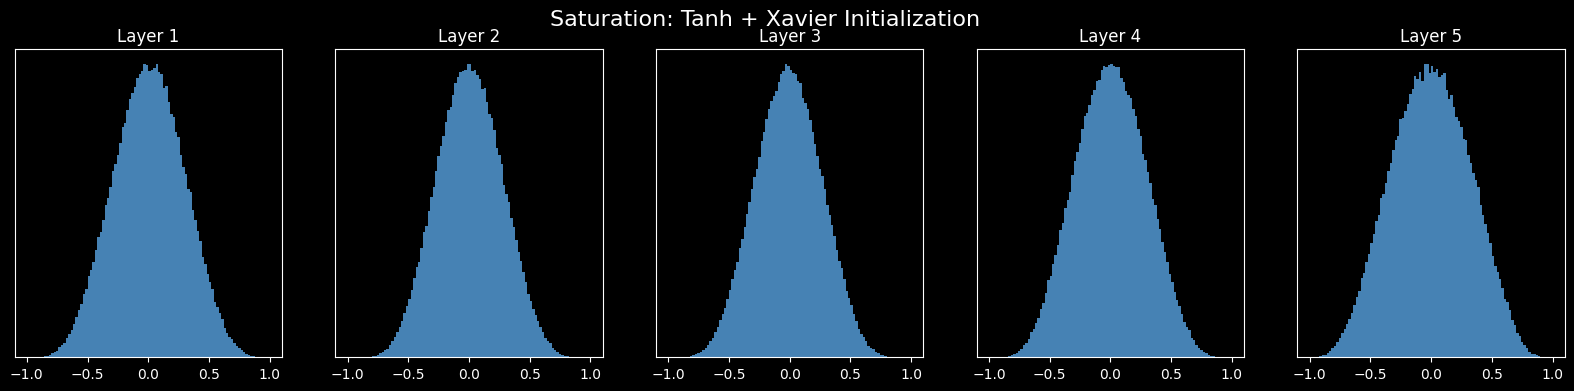

In [4]:
def plot_saturation_hists(model, title):
    _ = model.forward(X_val[:300]) # Trigger activation storage
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i in range(5):
        axes[i].hist(model.layer_a[i].flatten(), bins=100, range=(-1, 1), color='steelblue')
        axes[i].set_title(f"Layer {i+1}")
        axes[i].set_yticks([])
    plt.suptitle(title, fontsize=16)
    plt.show()

plot_saturation_hists(model_std, "Saturation: Tanh + Standard Initialization")
plot_saturation_hists(model_xav, "Saturation: Tanh + Xavier Initialization")

## Gradient Flow Analysis

The paper's primary metric for a good initialization is that the variance of the gradients should be similar across all layers. If the standard deviation of activations vanishes as we go deeper, the network cannot learn.

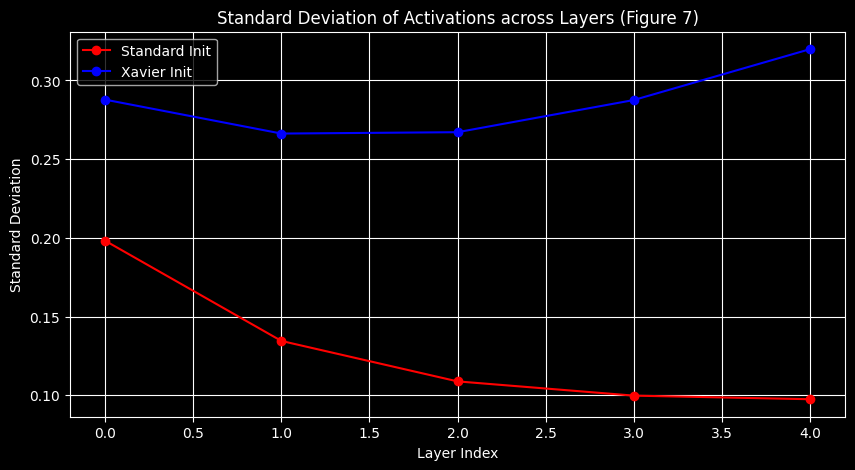

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(stats_std['activation_stds'][-1], 'ro-', label='Standard Init')
plt.plot(stats_xav['activation_stds'][-1], 'bo-', label='Xavier Init')

plt.title("Standard Deviation of Activations across Layers (Figure 7)")
plt.xlabel("Layer Index")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.show()

## Scientific Conclusion

* **Initialization Impact:** Standard initialization leads to a diminishing variance across layers, explaining the training difficulties in deep MLPs.
* **Xavier Efficiency:** The Normalized Initialization successfully maintains signal variance, keeping hidden units in the active (non-saturated) region of the Tanh function.
* **Activation Dynamics:** The logistic sigmoid's mean of 0.5 is naturally biased toward driving the subsequent layers into saturation at 0, making it unsuitable for deep networks compared to symmetric functions like Tanh.